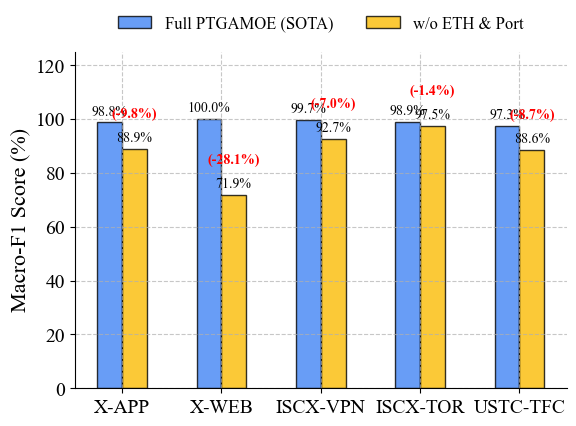

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 数据来源于论文 Table VI
datasets = ['X-APP', 'X-WEB', 'ISCX-VPN', 'ISCX-TOR', 'USTC-TFC']
sota_f1 = [98.78, 99.98, 99.65, 98.88, 97.34]
removed_f1 = [88.94, 71.87, 92.70, 97.45, 88.60]
deltas = [-9.84, -28.11, -6.95, -1.43, -8.74]

# 定义参考代码中的配色 (Chrome 风格)
chrome_blue = '#4285F4'
chrome_yellow = '#FBBC05'

# 设置字体为 Times New Roman
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams.update({'font.size': 14}) # 增大基础字号

# 设置柱状图的位置
indices = np.arange(len(datasets))
width = 0.25 # 保持细柱风格

# 创建画布，参考你的 (4, 3) 比例但稍大一点以容纳 5 个数据集
fig, ax = plt.subplots(figsize=(6, 4.5))

# 创建柱状图 (参考你提供的 bar 参数：edgecolor, align, alpha)
rects1 = ax.bar(indices, sota_f1, width=width, label='Full PTGAMOE (SOTA)', 
                color=chrome_blue, edgecolor='black', align='center', alpha=0.8)
rects2 = ax.bar(indices + width, removed_f1, width=width, label='w/o ETH & Port', 
                color=chrome_yellow, edgecolor='black', align='center', alpha=0.8)

# 添加标签和虚线网格 (参考你的 grid 设定)
ax.set_ylabel('Macro-F1 Score (%)', fontsize=16)
ax.set_xticks(indices + width / 2)
ax.set_xticklabels(datasets, rotation=0) # 5个词较短，建议 rotation=0 更美观
ax.grid(True, linestyle='--', alpha=0.7)

# 移除顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置 y 轴范围，留出标注空间
ax.set_ylim(0, 125)

# 图例放在上方并采用紧凑排列
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False, fontsize=12)

# 数值标注函数
def autolabel(rects, is_removed=False):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        # 柱顶 F1 值
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)
        
        # 在 Removed 柱上方标注红色 Delta (加粗)
        if is_removed:
            delta = deltas[i]
            ax.annotate(f'({delta:+.1f}%)',
                        xy=(rect.get_x() + rect.get_width() / 2, height + 8),
                        xytext=(0, 5),
                        textcoords="offset points",
                        ha='center', va='bottom', color='red', 
                        fontweight='bold', fontsize=10)

autolabel(rects1)
autolabel(rects2, is_removed=True)

plt.tight_layout()

# 保存高质量图片
plt.savefig('eth_port_ablation_styled.pdf', format='pdf')
plt.show()